# 承認済み部位別 before / after を解析する

`video_region_pair_candidates.ipynb` で固定した `selected_region_pairs.json` を使います。
現在選択されている部位だけを解析し、別部位のペアへ自動で置き換えません。


In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
marker = Path('analysis/analyze_selected_regions.py')
if (cwd / marker).is_file():
    REPO_ROOT = cwd
elif cwd.name == 'notebooks' and (cwd.parent / marker).is_file():
    REPO_ROOT = cwd.parent
    os.chdir(REPO_ROOT)
else:
    raise RuntimeError(f'ikiikimake のリポジトリ直下または notebooks/ から実行してください: current={cwd}')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('repo root:', Path.cwd())


repo root: C:\Users\mail\work\ikiikimake


In [2]:
VIDEO = Path('makeup0923.mp4')
OUTPUT = Path('outputs') / VIDEO.stem
SELECTED = OUTPUT / 'selected_region_pairs.json'
ANALYSIS_ROOT = OUTPUT / 'selected_region_analysis'

if not SELECTED.is_file():
    raise FileNotFoundError(f'部位別ペアが固定されていません: {SELECTED}')
print('selected:', SELECTED)


selected: outputs\makeup0923\selected_region_pairs.json


analysis: C:\Users\mail\work\ikiikimake\outputs\makeup0923\selected_region_analysis\167ffc9f21c3b647


指標,単位,before,after,差,状態
画面左眉下の皮膚の細かな質感コントラスト（中央値）,局所L*比 %,0.201,0.966,+0.766,ok
画面左眉下の皮膚の細かな質感コントラスト（p90）,局所L*比 %,0.783,3.232,+2.449,ok
画面右眉下の皮膚の細かな質感コントラスト（中央値）,局所L*比 %,0.145,0.742,+0.596,ok
画面右眉下の皮膚の細かな質感コントラスト（p90）,局所L*比 %,0.489,2.754,+2.265,ok
画面左頬の細かな質感コントラスト（中央値・対照）,局所L*比 %,0.138,0.257,+0.118,ok
画面左頬の細かな質感コントラスト（p90・対照）,局所L*比 %,0.356,0.901,+0.545,ok
画面右頬の細かな質感コントラスト（中央値・対照）,局所L*比 %,0.120,0.194,+0.074,ok
画面右頬の細かな質感コントラスト（p90・対照）,局所L*比 %,0.316,0.594,+0.278,ok
額の細かな質感コントラスト（中央値・対照）,局所L*比 %,0.048,0.085,+0.037,ok
額の細かな質感コントラスト（p90・対照）,局所L*比 %,0.192,0.313,+0.121,ok

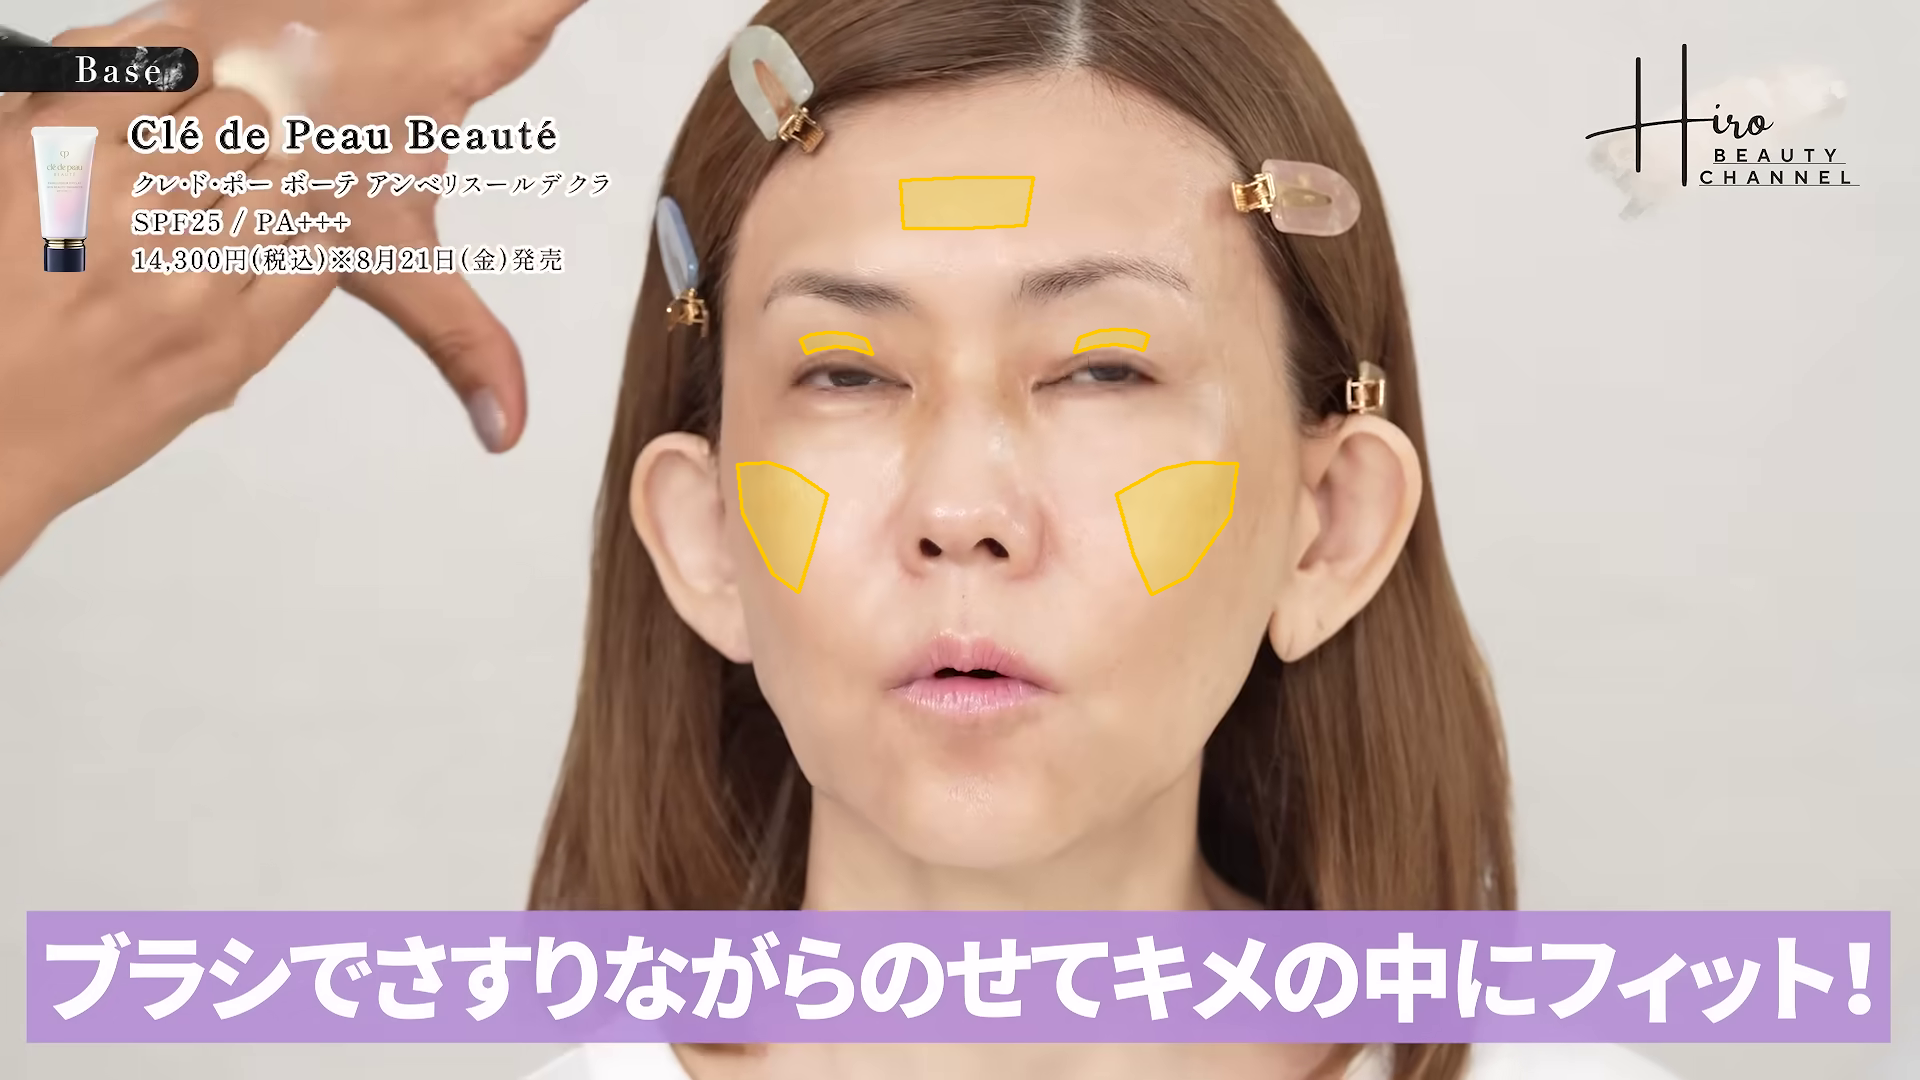
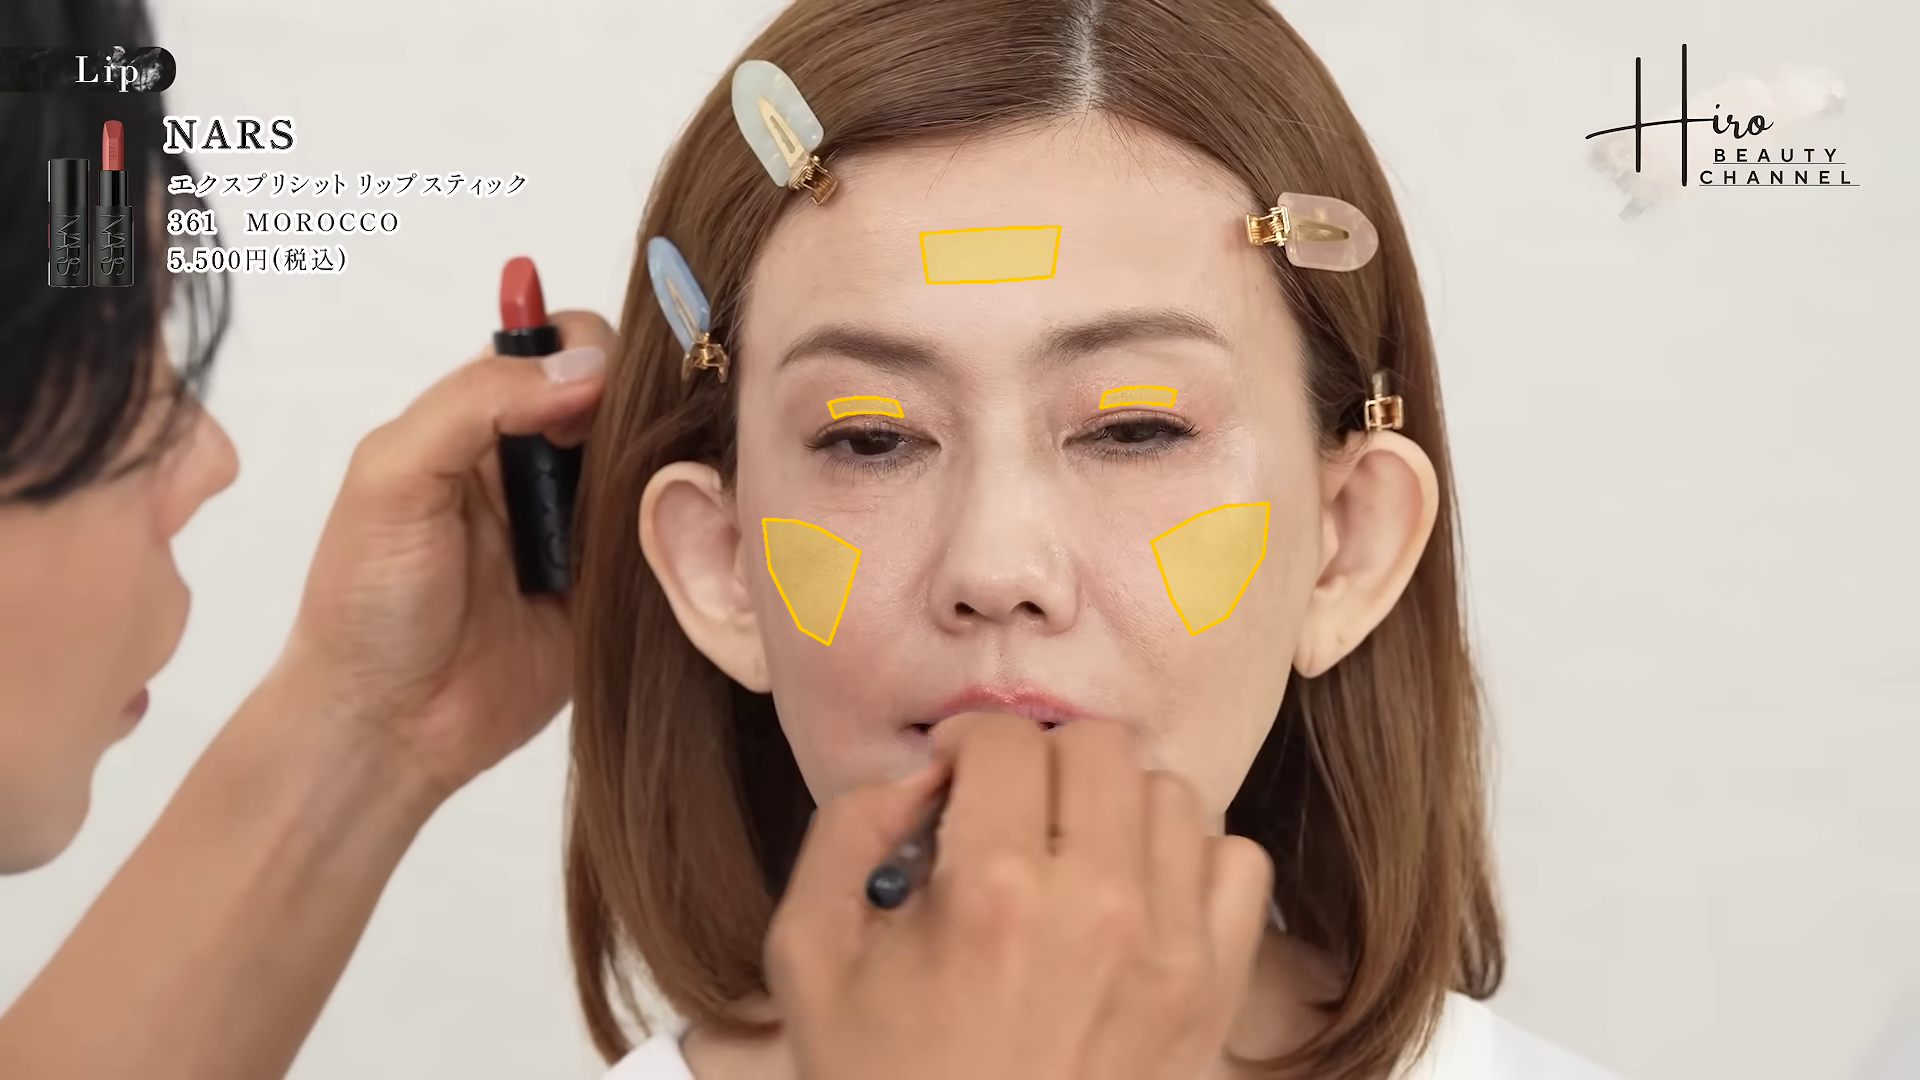

In [3]:
from analysis.analyze_selected_regions import ANALYSIS_VERSION, analyze_selected_regions
EXPECTED_ANALYSIS_VERSION = 'selected-region-appearance-v9'
if ANALYSIS_VERSION != EXPECTED_ANALYSIS_VERSION:
    raise RuntimeError(
        f'解析モジュールが古いです: loaded={ANALYSIS_VERSION}, expected={EXPECTED_ANALYSIS_VERSION}. '
        'Jupyter kernel を再起動して Run All してください。'
    )
from IPython.display import HTML, display
import base64

summary = analyze_selected_regions(SELECTED, ANALYSIS_ROOT)
RUN_DIR = Path(summary['output_dir'])
print('analysis:', RUN_DIR)

# report.html 内の相対画像パスは VS Code/Jupyter の HTML 表示では
# notebook 側を基準に解決されて壊れるため、表示時だけ data URI に埋め込む。
report_html = (RUN_DIR / 'report.html').read_text(encoding='utf-8')
for region in summary['regions']:
    for phase in ('before', 'after'):
        filename = f'{region}_{phase}.png'
        image_path = RUN_DIR / filename
        if not image_path.is_file():
            raise FileNotFoundError(image_path)
        encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
        report_html = report_html.replace(
            f"src='{filename}'",
            f"src='data:image/png;base64,{encoded}'",
        )
display(HTML(report_html))


In [4]:
for region, result in summary['regions'].items():
    print('\n', region)
    for row in result['deltas']:
        before = row['before']
        after = row['after']
        delta = row['delta']
        print(f"{row['label']}: {before:.4f} -> {after:.4f}  delta={delta:+.4f}")
print('\nreport:', RUN_DIR / 'report.html')
print('csv   :', RUN_DIR / 'feature_deltas.csv')



 eye_texture
画面左眉下の皮膚の細かな質感コントラスト（中央値）: 0.2006 -> 0.9664  delta=+0.7659
画面左眉下の皮膚の細かな質感コントラスト（p90）: 0.7828 -> 3.2321  delta=+2.4493
画面右眉下の皮膚の細かな質感コントラスト（中央値）: 0.1453 -> 0.7417  delta=+0.5965
画面右眉下の皮膚の細かな質感コントラスト（p90）: 0.4894 -> 2.7544  delta=+2.2650
画面左頬の細かな質感コントラスト（中央値・対照）: 0.1383 -> 0.2566  delta=+0.1183
画面左頬の細かな質感コントラスト（p90・対照）: 0.3559 -> 0.9011  delta=+0.5452
画面右頬の細かな質感コントラスト（中央値・対照）: 0.1196 -> 0.1935  delta=+0.0739
画面右頬の細かな質感コントラスト（p90・対照）: 0.3156 -> 0.5941  delta=+0.2784
額の細かな質感コントラスト（中央値・対照）: 0.0481 -> 0.0846  delta=+0.0365
額の細かな質感コントラスト（p90・対照）: 0.1917 -> 0.3130  delta=+0.1212
画面左眉下の皮膚のSEsc-inspired bright-scaliness率: 0.0000 -> 0.0000  delta=+0.0000
画面右眉下の皮膚のSEsc-inspired bright-scaliness率: 0.0000 -> 0.0000  delta=+0.0000
画面左頬・対照のSEsc-inspired bright-scaliness率: 0.0000 -> 0.0000  delta=+0.0000
画面右頬・対照のSEsc-inspired bright-scaliness率: 0.0000 -> 0.0000  delta=+0.0000
額・対照のSEsc-inspired bright-scaliness率: 0.0000 -> 0.0000  delta=+0.0000
画面左眉下の皮膚のGVR-inspired皮膚水分反射比: 0.0000 -> 0.00

## 眉下の皮膚と対照 ROI を拡大して確認する

眉下の皮膚に加えて、同じ固定フレームの左右頬・額を対照 ROI として before / after で拡大表示します。黄色が実際の計測領域です。


C:\Users\mail\AppData\Local\Temp\ipykernel_9432\1054327821.py:83: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  fig.savefig(closeup_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\1054327821.py:83: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.savefig(closeup_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\1054327821.py:83: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  fig.savefig(closeup_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\1054327821.py:83: UserWarning: Glyph 30473 (\N{CJK UNIFIED IDEOGRAPH-7709}) missing from font(s) DejaVu Sans.
  fig.savefig(closeup_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\1054327821.py:83: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from

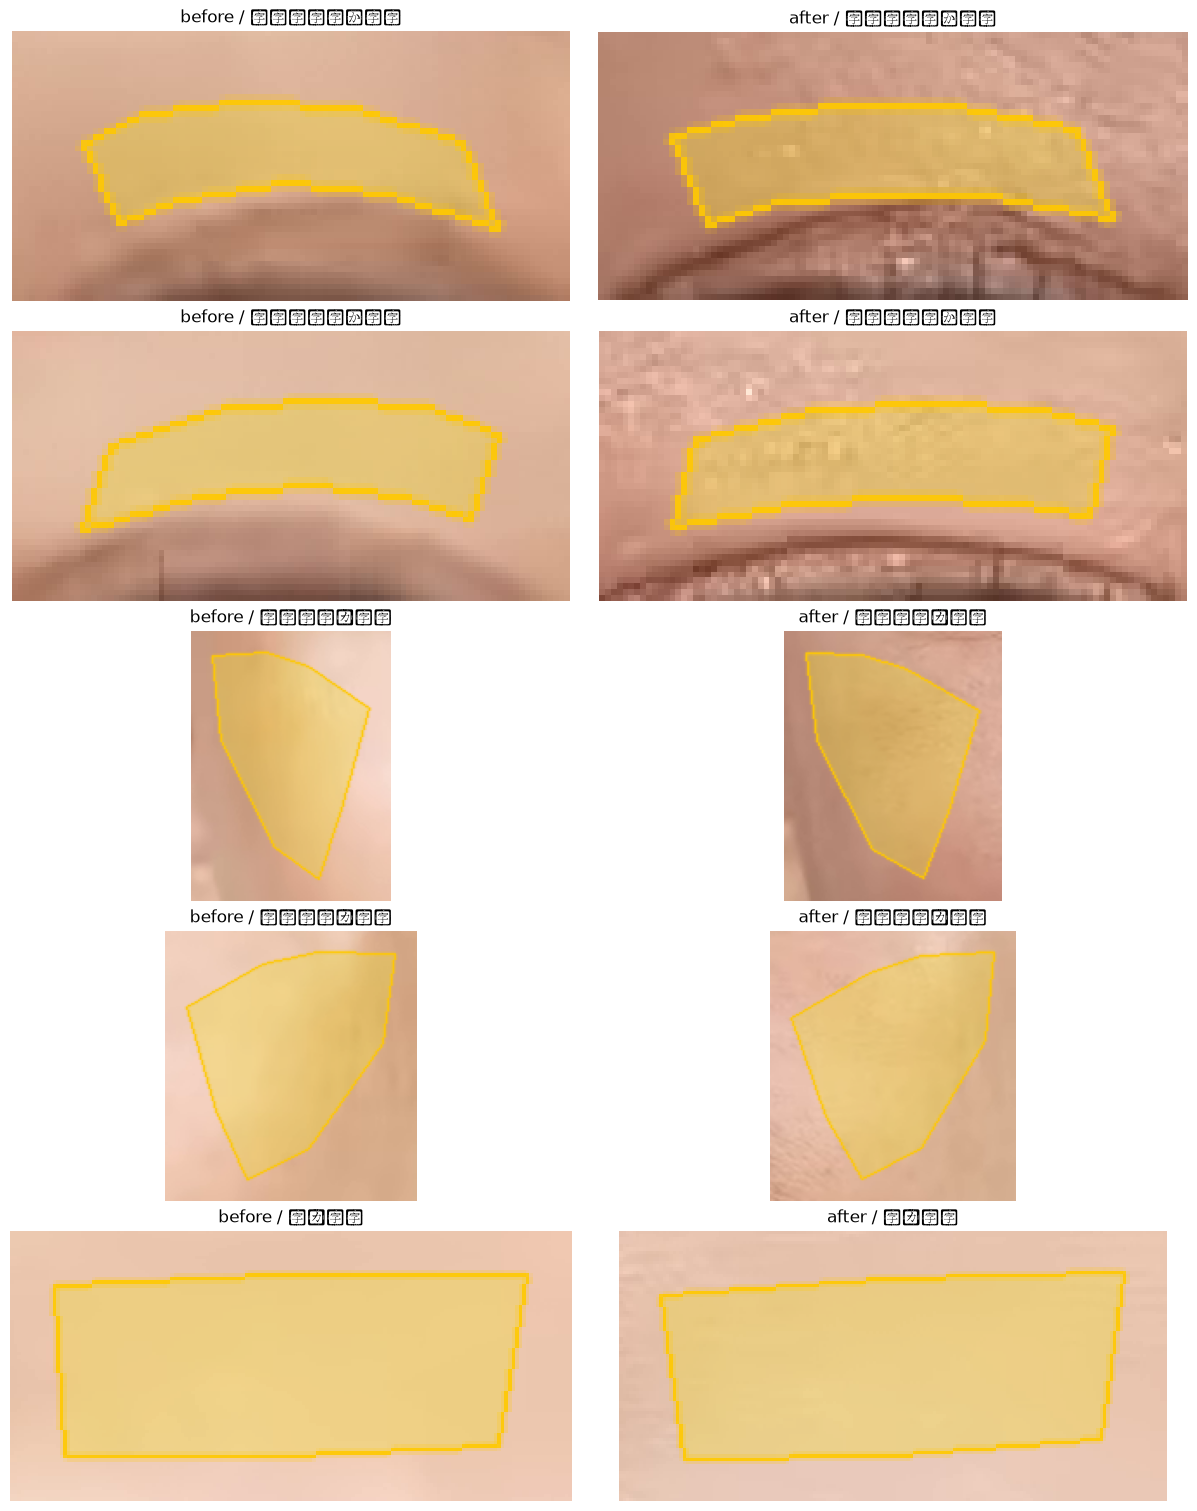

closeup: C:\Users\mail\work\ikiikimake\outputs\makeup0923\selected_region_analysis\167ffc9f21c3b647\eye_texture_closeup.png


In [5]:
from pathlib import Path
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

# notebook を repo 直下 / notebooks/ のどちらから実行しても同じ場所を指す。
cwd = Path.cwd().resolve()
marker = Path('analysis/analyze_selected_regions.py')
if (cwd / marker).is_file():
    project_root = cwd
elif cwd.name == 'notebooks' and (cwd.parent / marker).is_file():
    project_root = cwd.parent
    os.chdir(project_root)
else:
    raise RuntimeError(f'ikiikimake のリポジトリ直下または notebooks/ から実行してください: current={cwd}')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from analysis.analyze_selected_regions import ANALYSIS_VERSION, analyze_selected_regions, _load_phase
EXPECTED_ANALYSIS_VERSION = 'selected-region-appearance-v9'
if ANALYSIS_VERSION != EXPECTED_ANALYSIS_VERSION:
    raise RuntimeError(
        f'解析モジュールが古いです: loaded={ANALYSIS_VERSION}, expected={EXPECTED_ANALYSIS_VERSION}. '
        'Jupyter kernel を再起動して Run All してください。'
    )

video = Path('makeup0923.mp4')
output = Path('outputs') / video.stem
selected_path = output / 'selected_region_pairs.json'
analysis_root = output / 'selected_region_analysis'
if not selected_path.is_file():
    raise FileNotFoundError(selected_path)

closeup_summary = analyze_selected_regions(selected_path, analysis_root)
region = 'eye_texture'
if region not in closeup_summary['regions']:
    raise ValueError(f'{region} が selected_region_pairs.json にありません。')
selection = closeup_summary['regions'][region]['selection']
before_img, before_masks, _ = _load_phase(selection['before'], region)
after_img, after_masks, _ = _load_phase(selection['after'], region)

def make_closeup(image, mask, pad_face_fraction=0.035):
    mask = np.asarray(mask, dtype=bool)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        raise ValueError('ROI mask is empty')
    face_width = xs.max() - xs.min() + 1
    pad = max(12, round(face_width * pad_face_fraction))
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(image.shape[0], int(ys.max()) + pad + 1)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(image.shape[1], int(xs.max()) + pad + 1)
    crop = image[y0:y1, x0:x1].copy()
    local_mask = mask[y0:y1, x0:x1]
    fill = crop.copy()
    fill[local_mask] = (50, 220, 240)
    overlay = cv2.addWeighted(fill, 0.35, crop, 0.65, 0)
    contours = cv2.findContours(local_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    cv2.drawContours(overlay, contours, -1, (0, 200, 255), 1, cv2.LINE_AA)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

mask_names = [
    ('screen_left_upper_lid_skin', '画面左眉下の皮膚'),
    ('screen_right_upper_lid_skin', '画面右眉下の皮膚'),
    ('left_cheek', '画面左頬・対照'),
    ('right_cheek', '画面右頬・対照'),
    ('forehead', '額・対照'),
]

fig, axes = plt.subplots(5, 2, figsize=(12, 15), constrained_layout=True)
for row, (mask_name, label) in enumerate(mask_names):
    axes[row, 0].imshow(make_closeup(before_img, before_masks[mask_name]))
    axes[row, 0].set_title(f'before / {label}')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(make_closeup(after_img, after_masks[mask_name]))
    axes[row, 1].set_title(f'after / {label}')
    axes[row, 1].axis('off')

run_dir = Path(closeup_summary['output_dir'])
closeup_path = run_dir / 'eye_texture_closeup.png'
fig.savefig(closeup_path, dpi=180, bbox_inches='tight')
plt.show()
print('closeup:', closeup_path)


## ほうれい線候補 ROI と周囲皮膚対照帯を目視確認する

小鼻から口角手前へ向かう二次Bezier曲線を頬側へふくらませた候補帯です。黄色がほうれい線候補、シアンがさらに頬側の周囲皮膚対照帯です。before / after は各側で同じクロップサイズにそろえて表示します。ここではまだシワそのものを検出・数値化しません。


C:\Users\mail\AppData\Local\Temp\ipykernel_9432\2338169146.py:74: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  fig.savefig(nasolabial_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\2338169146.py:74: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.savefig(nasolabial_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\2338169146.py:74: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  fig.savefig(nasolabial_path, dpi=180, bbox_inches='tight')
C:\Users\mail\AppData\Local\Temp\ipykernel_9432\2338169146.py:74: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  fig.savefig(nasolabial_path, dpi=180, bbox_inches='tight')


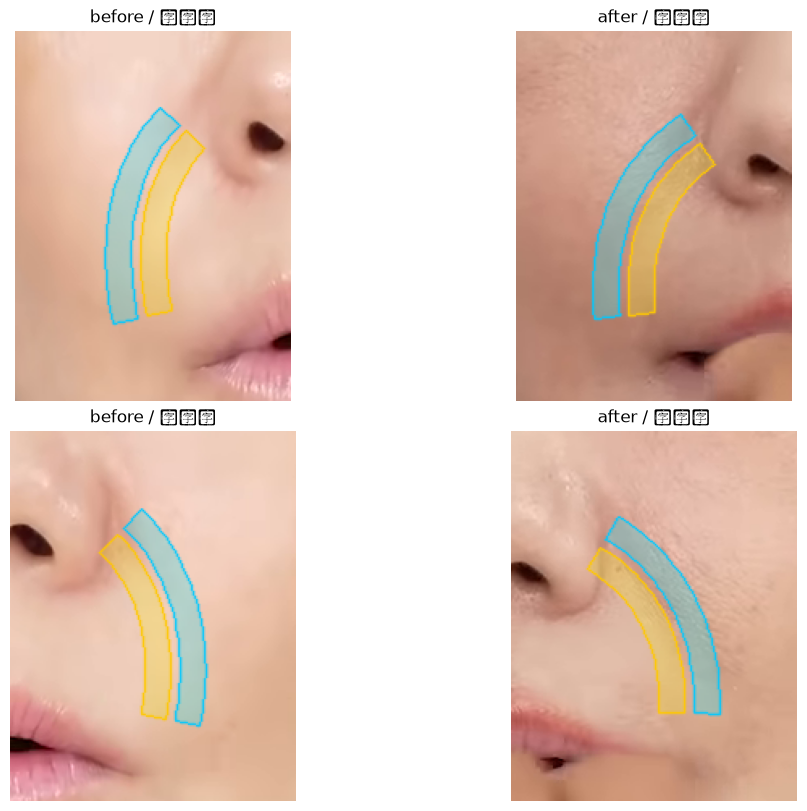

nasolabial curve review: C:\Users\mail\work\ikiikimake\outputs\makeup0923\selected_region_analysis\167ffc9f21c3b647\nasolabial_curve_review.png


In [6]:
nasolabial_sides = [
    ('screen_left', '画面左'),
    ('screen_right', '画面右'),
]

def _mask_bounds(mask):
    mask = np.asarray(mask, dtype=bool)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        raise ValueError('ROI mask is empty')
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

def _fixed_crop_bounds(mask_union, crop_width, crop_height, image_shape):
    x0, y0, x1, y1 = _mask_bounds(mask_union)
    cx = 0.5 * (x0 + x1)
    cy = 0.5 * (y0 + y1)
    height, width = image_shape[:2]
    if crop_width > width or crop_height > height:
        raise ValueError('Requested fixed crop is larger than source image')
    left = int(round(cx - crop_width / 2))
    top = int(round(cy - crop_height / 2))
    left = min(max(0, left), width - crop_width)
    top = min(max(0, top), height - crop_height)
    return left, top, left + crop_width, top + crop_height

def _overlay_nasolabial(image, candidate, control, crop_width, crop_height):
    union = np.asarray(candidate, dtype=bool) | np.asarray(control, dtype=bool)
    x0, y0, x1, y1 = _fixed_crop_bounds(union, crop_width, crop_height, image.shape)
    crop = image[y0:y1, x0:x1].copy()
    candidate_local = np.asarray(candidate[y0:y1, x0:x1], dtype=bool)
    control_local = np.asarray(control[y0:y1, x0:x1], dtype=bool)

    fill = crop.copy()
    fill[candidate_local] = (50, 220, 240)
    fill[control_local] = (240, 220, 50)
    overlay = cv2.addWeighted(fill, 0.32, crop, 0.68, 0)

    candidate_contours = cv2.findContours(candidate_local.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    control_contours = cv2.findContours(control_local.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    cv2.drawContours(overlay, candidate_contours, -1, (0, 200, 255), 1, cv2.LINE_AA)
    cv2.drawContours(overlay, control_contours, -1, (255, 200, 0), 1, cv2.LINE_AA)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for row, (side, label) in enumerate(nasolabial_sides):
    candidate_name = f'{side}_nasolabial_candidate'
    control_name = f'{side}_nasolabial_outer_control'
    for name in (candidate_name, control_name):
        if name not in before_masks or name not in after_masks:
            raise RuntimeError(f'ほうれい線レビュー ROI がありません: {name}')

    before_union = before_masks[candidate_name] | before_masks[control_name]
    after_union = after_masks[candidate_name] | after_masks[control_name]
    before_box = _mask_bounds(before_union)
    after_box = _mask_bounds(after_union)
    roi_width = max(before_box[2] - before_box[0] + 1, after_box[2] - after_box[0] + 1)
    roi_height = max(before_box[3] - before_box[1] + 1, after_box[3] - after_box[1] + 1)
    pad = max(24, round(max(roi_width, roi_height) * 0.35))
    crop_width = roi_width + 2 * pad
    crop_height = roi_height + 2 * pad

    axes[row, 0].imshow(_overlay_nasolabial(
        before_img, before_masks[candidate_name], before_masks[control_name], crop_width, crop_height
    ))
    axes[row, 0].set_title(f'before / {label}')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(_overlay_nasolabial(
        after_img, after_masks[candidate_name], after_masks[control_name], crop_width, crop_height
    ))
    axes[row, 1].set_title(f'after / {label}')
    axes[row, 1].axis('off')

nasolabial_path = run_dir / 'nasolabial_curve_review.png'
fig.savefig(nasolabial_path, dpi=180, bbox_inches='tight')
plt.show()
print('nasolabial curve review:', nasolabial_path)
